Facial Expression Prediction

Dataset:
- https://www.kaggle.com/datasets/msambare/fer2013/data

In [47]:
import torch
import torchvision
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [49]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)
print("isi source:", os.listdir(path))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013
isi source: ['test', 'train']


Helper Download Data

In [50]:
from pathlib import Path
import kagglehub
import shutil

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def create_dataloader(
    root: str,
    transform_train: transforms.Compose,
    transform_test: transforms.Compose,
    batch_size: int,
    num_workers: int = 4,
):
    source_path = Path(kagglehub.dataset_download("msambare/fer2013"))
    destination_path = Path(root) / "fer2013"

    # Copy dataset sekali saja
    if not destination_path.exists():
        shutil.copytree(source_path, destination_path)

    train_dataset = datasets.ImageFolder(
        root=destination_path / "train",
        transform=transform_train
    )

    test_dataset = datasets.ImageFolder(
        root=destination_path / "test",
        transform=transform_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    class_names = train_dataset.classes

    print("Classes:", class_names)
    print(f"Train: {len(train_dataset)}")
    print(f"Test : {len(test_dataset)}")

    return (
        train_loader,
        test_loader,
        train_dataset,
        test_dataset,
        class_names
    )

Helper Save

In [51]:
import torch
from pathlib import Path


def save_checkpoint(
    model: torch.nn.Module,
    model_path: str | Path,
    class_names: list[str],
):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
    }

    torch.save(checkpoint, model_path)

    print(f"[INFO] Checkpoint saved to: {model_path}")

Helper Training

In [52]:
import torch
import torchvision
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from pathlib import Path
from PIL import Image, ImageOps


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

class EarlyStopping:

    def __init__(self, patience=3):

        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.best_weights = None

    def __call__(self, model, val_loss):

        stop = False

        if val_loss < self.best_loss:

            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())

        else:

            self.counter += 1

            if self.counter >= self.patience:
                stop = True

        return stop


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device,
          class_names: list[str],
          save_model_path: str | Path,
          scheduler=None) -> Dict[str, List]:

  early_stopping = EarlyStopping(patience=3)

  best_acc = 0
  best_weights = None

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  train_start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    scheduler.step(test_loss)

    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = copy.deepcopy(model.state_dict())

        save_checkpoint(
            model=model,
            model_path=save_model_path,
            class_names=class_names,
        )

        print(f"Best model saved (acc={best_acc:.4f})")

    if early_stopping(model, test_loss):
      print("Early Stopping!")
      break

    print(f"epoch : {epoch + 1} | train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss : {test_loss:.4f} | test_acc : {test_acc:.4f}\n")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  if best_weights is not None:
    model.load_state_dict(best_weights)

  train_end_time = timer()

  print(f"Waktu Yang Dibutuhkan Training : {train_end_time - train_start_time:.3f} seconds")

  return results

def predict(model, image_path, device, transform=None):
    if device is None:
        device = next(model.parameters()).device

    image = Image.open(image_path).convert("RGB")

    if transform is not None:
        image = transform(image)

    image = image.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    prob = probs.max().item()
    return pred, prob

Transforms

In [53]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

In [54]:
train_loader, test_loader, data_train, data_test, class_names = create_dataloader(
    root="data",
    transform_train=train_transform,
    transform_test=test_transform,
    batch_size=32,
    num_workers=2
)

Using Colab cache for faster access to the 'fer2013' dataset.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 28709
Test : 7178


In [55]:
class_names = data_train.classes
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

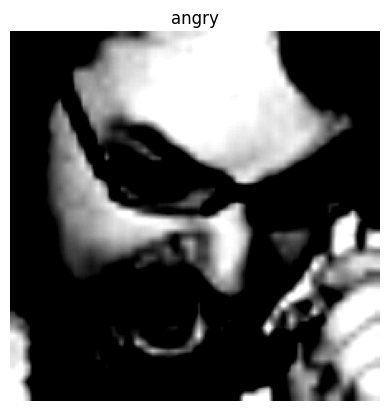

In [56]:
img, label = data_test[0]

plt.imshow(img.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)
plt.show()

In [57]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset = datasets.ImageFolder(
    root="data/fer2013/train",
    transform=transforms.ToTensor()
)

loader = DataLoader(dataset, batch_size=64, shuffle=False)

mean = 0.
std = 0.

for images, _ in loader:
    mean += images.mean(dim=[0, 2, 3])
    std += images.std(dim=[0, 2, 3])

mean /= len(loader)
std /= len(loader)

print(mean)
print(std)

tensor([0.5078, 0.5078, 0.5078])
tensor([0.2528, 0.2528, 0.2528])


In [58]:
def test_accuracy(model, dataset, device):
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            logits = model(image)
            pred = logits.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return correct / total

In [59]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=model.classifier[1].in_features,
                    out_features=len(class_names))
)

model = model.to(device)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Check Before Training Accuracy

In [60]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy Before: {model_acc:.2%}")

Data Accuracy Before: 13.19%


In [61]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

Check Accuracy Small Datasets

In [62]:
X, y = next(iter(train_loader))

X = X.to(device)

model.eval()

with torch.no_grad():
    out = model(X)

print(out.shape)
print(out[0])

torch.Size([32, 7])
tensor([-0.0939,  0.2274,  0.3328, -0.1192,  0.0403,  0.0456, -0.4523],
       device='cuda:0')


In [63]:
train_indices = torch.randperm(len(data_train))[:100]
test_indices = torch.randperm(len(data_test))[:100]

train_subset = Subset(data_train, train_indices)
test_subset = Subset(data_test, test_indices)

len(train_subset), len(test_subset)

(100, 100)

In [64]:
train_subset_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
)

test_subset_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

len(train_subset), len(test_subset)

(100, 100)

In [65]:
results = train(
    model=model,
    train_dataloader=train_subset_loader,
    test_dataloader=test_subset_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=20,
    device=device,
    class_names=class_names,
    save_model_path="models/facial_expression_model_efficientnet_b0_trained_experiments.pth",
    scheduler=scheduler
)

  0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.0625)
epoch : 1 | train_loss : 1.9165 | train_acc : 0.2031 | test_loss : 1.9452 | test_acc : 0.0625

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.1016)
epoch : 2 | train_loss : 1.8409 | train_acc : 0.2344 | test_loss : 1.9315 | test_acc : 0.1016

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.1406)
epoch : 3 | train_loss : 1.8158 | train_acc : 0.2422 | test_loss : 1.9210 | test_acc : 0.1406

epoch : 4 | train_loss : 1.7040 | train_acc : 0.3047 | test_loss : 1.9119 | test_acc : 0.1250

epoch : 5 | train_loss : 1.6412 | train_acc : 0.3984 | test_loss : 1.8900 | test_acc : 0.1250

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.1797)
epoch : 6

Train Large Datasets

In [66]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

results_stage1 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=3,          # classifier yang dilatih
    device=device,
    class_names=class_names,
    save_model_path="models/facial_expression_model_efficientnet_b0_trained_experiments.pth",
    scheduler=scheduler
)

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.4184)
epoch : 1 | train_loss : 1.6682 | train_acc : 0.3792 | test_loss : 1.5976 | test_acc : 0.4184

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.4294)
epoch : 2 | train_loss : 1.6188 | train_acc : 0.4112 | test_loss : 1.5832 | test_acc : 0.4294

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.4358)
epoch : 3 | train_loss : 1.6102 | train_acc : 0.4135 | test_loss : 1.5669 | test_acc : 0.4358

Waktu Yang Dibutuhkan Training : 269.867 seconds


In [67]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

results_stage2 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=10,
    device=device,
    class_names=class_names,
    save_model_path="models/facial_expression_model_efficientnet_b0_trained_experiments.pth",
    scheduler=scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.6139)
epoch : 1 | train_loss : 1.3686 | train_acc : 0.5485 | test_loss : 1.2345 | test_acc : 0.6139

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.6528)
epoch : 2 | train_loss : 1.1952 | train_acc : 0.6403 | test_loss : 1.1773 | test_acc : 0.6528

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.6697)
epoch : 3 | train_loss : 1.1070 | train_acc : 0.6855 | test_loss : 1.1389 | test_acc : 0.6697

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best model saved (acc=0.6765)
epoch : 4 | train_loss : 1.0312 | train_acc : 0.7249 | test_loss : 1.1369 | test_acc : 0.6765

[INFO] Checkpoint saved to: models/facial_expression_model_efficientnet_b0_trained_experiments.pth
Best 

In [68]:
correct = 0
total = 0

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Acc     : {correct/total:.4f}")

Correct : 4966
Total   : 7178
Acc     : 0.6918


Result 1

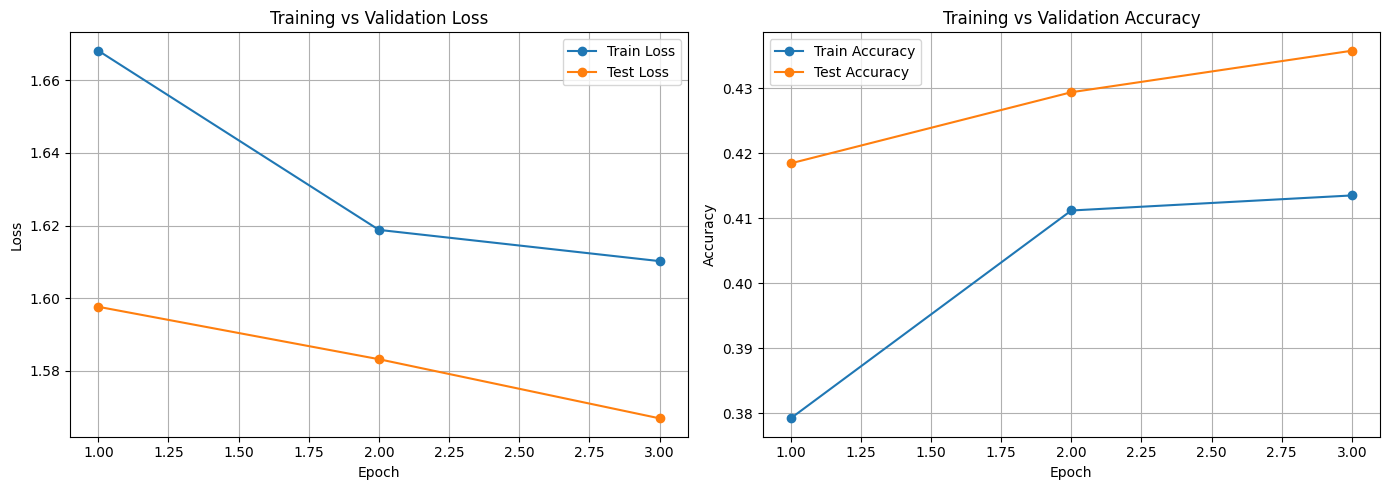

In [69]:
import matplotlib.pyplot as plt

train_loss = results_stage1["train_loss"]
test_loss = results_stage1["test_loss"]
train_acc = results_stage1["train_acc"]
test_acc = results_stage1["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Result 2

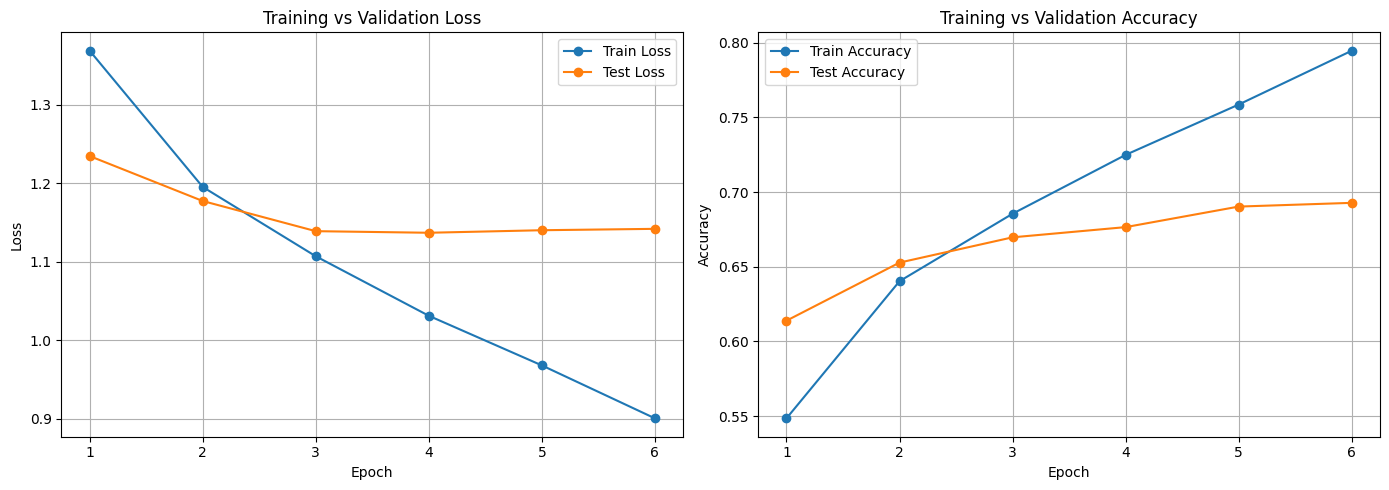

In [70]:
import matplotlib.pyplot as plt

train_loss = results_stage2["train_loss"]
test_loss = results_stage2["test_loss"]
train_acc = results_stage2["train_acc"]
test_acc = results_stage2["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Accuracy After Train

In [71]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy After Training : {model_acc:.2%}")

Data Accuracy After Training : 69.18%


Lets Prediction

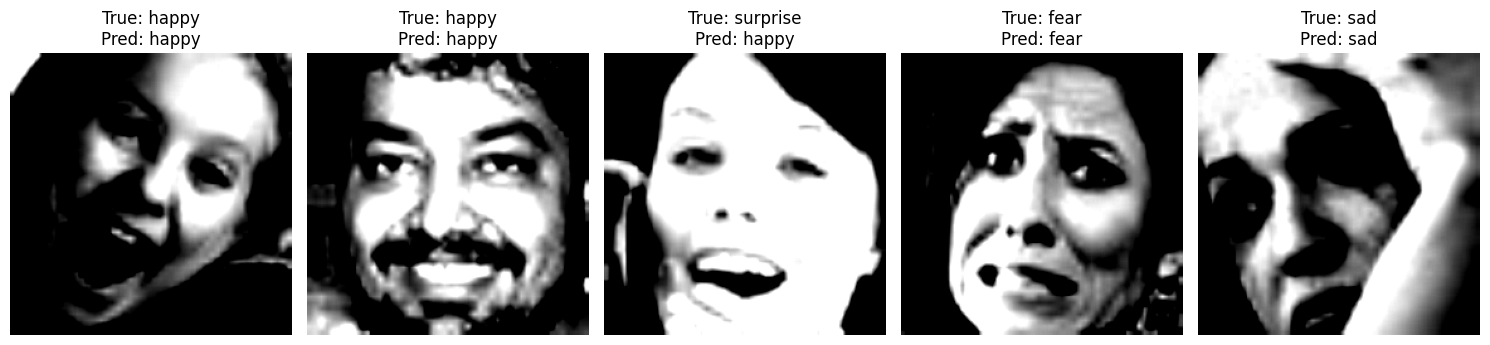

In [72]:
import random

random_indices = random.sample(range(len(data_test)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
model.eval()

for i, idx in enumerate(random_indices):
    img, true_label = data_test[idx]

    with torch.inference_mode():
        logits = model(img.unsqueeze(0).to(device))
        pred_label = logits.argmax(dim=1).item()

    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

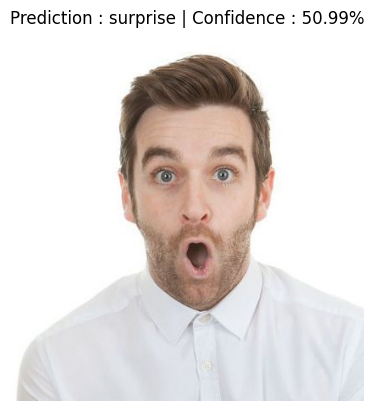

In [73]:
from PIL import Image

path_data = Path("data/")
image_path = path_data / "prediction_image/predict_image.jpg"

image = Image.open(image_path)

transforms_pred = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5078, 0.5078, 0.5078],
        std=[0.2528, 0.2528, 0.2528]
    )
])

pred, prob = predict(
    model=model,
    image_path=image_path,
    device=device,
    transform=transforms_pred,
)

plt.imshow(image)
plt.title(f"Prediction : {class_names[pred]} | Confidence : {prob:.2%}")
plt.axis("off")
plt.show()